In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data.
df = pd.read_csv('data/1900_2021_DISASTERS.xlsx - emdat data.csv', encoding='latin-1')

# Let’s see what the data looks like.
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nPehli 5 rows:")
df.head()

Shape: (16126, 45)

Columns: ['Year', 'Seq', 'Glide', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'Disaster Subsubtype', 'Event Name', 'Country', 'ISO', 'Region', 'Continent', 'Location', 'Origin', 'Associated Dis', 'Associated Dis2', 'OFDA Response', 'Appeal', 'Declaration', 'Aid Contribution', 'Dis Mag Value', 'Dis Mag Scale', 'Latitude', 'Longitude', 'Local Time', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No Injured', 'No Affected', 'No Homeless', 'Total Affected', "Insured Damages ('000 US$)", "Total Damages ('000 US$)", 'CPI', 'Adm Level', 'Admin1 Code', 'Admin2 Code', 'Geo Locations']

Pehli 5 rows:


,Year,Seq,Glide,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,Disaster Subsubtype,Event Name,Country,...,No Affected,No Homeless,Total Affected,Insured Damages ('000 US$),Total Damages ('000 US$),CPI,Adm Level,Admin1 Code,Admin2 Code,Geo Locations
0,1900,9002,NaN,Natural,Climatological,Drought,Drought,NaN,NaN,Cabo Verde,...,NaN,NaN,NaN,NaN,NaN,3.221647,NaN,NaN,NaN,NaN
1,1900,9001,NaN,Natural,Climatological,Drought,Drought,NaN,NaN,India,...,NaN,NaN,NaN,NaN,NaN,3.221647,NaN,NaN,NaN,NaN
2,1902,12,NaN,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,Guatemala,...,NaN,NaN,NaN,NaN,25000.0,3.350513,NaN,NaN,NaN,NaN
3,1902,3,NaN,Natural,Geophysical,Volcanic activity,Ash fall,NaN,Santa Maria,Guatemala,...,NaN,NaN,NaN,NaN,NaN,3.350513,NaN,NaN,NaN,NaN
4,1902,10,NaN,Natural,Geophysical,Volcanic activity,Ash fall,NaN,Santa Maria,Guatemala,...,NaN,NaN,NaN,NaN,NaN,3.350513,NaN,NaN,NaN,NaN


In [ ]:
# Check how many missing values there are.
print("Missing Values:")
print(df.isnull().sum())

# Calculate the total number of rows and the percentage of missing values.
print("\nMissing Percentage:")
missing = (df.isnull().sum() / len(df)) * 100
print(missing[missing > 0].sort_values(ascending=False))

Missing Values:
Year                              0
Seq                               0
Glide                         14545
Disaster Group                    0
Disaster Subgroup                 0
Disaster Type                     0
Disaster Subtype               3110
Disaster Subsubtype           15049
Event Name                    12265
Country                           0
ISO                               0
Region                            0
Continent                         0
Location                       1792
Origin                        12332
Associated Dis                12778
Associated Dis2               15419
OFDA Response                 14432
Appeal                        13557
Declaration                   12870
Aid Contribution              15449
Dis Mag Value                 11180
Dis Mag Scale                  1190
Latitude                      13397
Longitude                     13394
Local Time                    15023
River Basin                   14839
Start Year  

In [5]:
print(df.columns.tolist())

['Year', 'Seq', 'Glide', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'Disaster Subsubtype', 'Event Name', 'Country', 'ISO', 'Region', 'Continent', 'Location', 'Origin', 'Associated Dis', 'Associated Dis2', 'OFDA Response', 'Appeal', 'Declaration', 'Aid Contribution', 'Dis Mag Value', 'Dis Mag Scale', 'Latitude', 'Longitude', 'Local Time', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No Injured', 'No Affected', 'No Homeless', 'Total Affected', "Insured Damages ('000 US$)", "Total Damages ('000 US$)", 'CPI', 'Adm Level', 'Admin1 Code', 'Admin2 Code', 'Geo Locations']


In [ ]:

# Keep only the important columns.
important_cols = ['Year', 'Disaster Group', 'Disaster Subgroup', 
                  'Disaster Type', 'Country', 'Continent', 'Region',
                  'Total Deaths', 'No Injured', 'No Affected', 
                  'No Homeless', 'Total Affected', "Total Damages ('000 US$)"]

# Take only these columns.
df_clean = df[important_cols].copy()

# Fill missing values in numeric columns with 0.
num_cols = ['Total Deaths', 'No Injured', 'No Affected', 
            'No Homeless', 'Total Affected', "Total Damages ('000 US$)"]

df_clean[num_cols] = df_clean[num_cols].fillna(0)

print("Clean data shape:", df_clean.shape)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

# Save the cleaned data.
df_clean.to_csv('data/disasters_clean.csv', index=False)
print("\n✅ disasters_clean.csv saved!")

Clean data shape: (16126, 13)

Missing values after cleaning:
Year                        0
Disaster Group              0
Disaster Subgroup           0
Disaster Type               0
Country                     0
Continent                   0
Region                      0
Total Deaths                0
No Injured                  0
No Affected                 0
No Homeless                 0
Total Affected              0
Total Damages ('000 US$)    0
dtype: int64

✅ disasters_clean.csv saved!


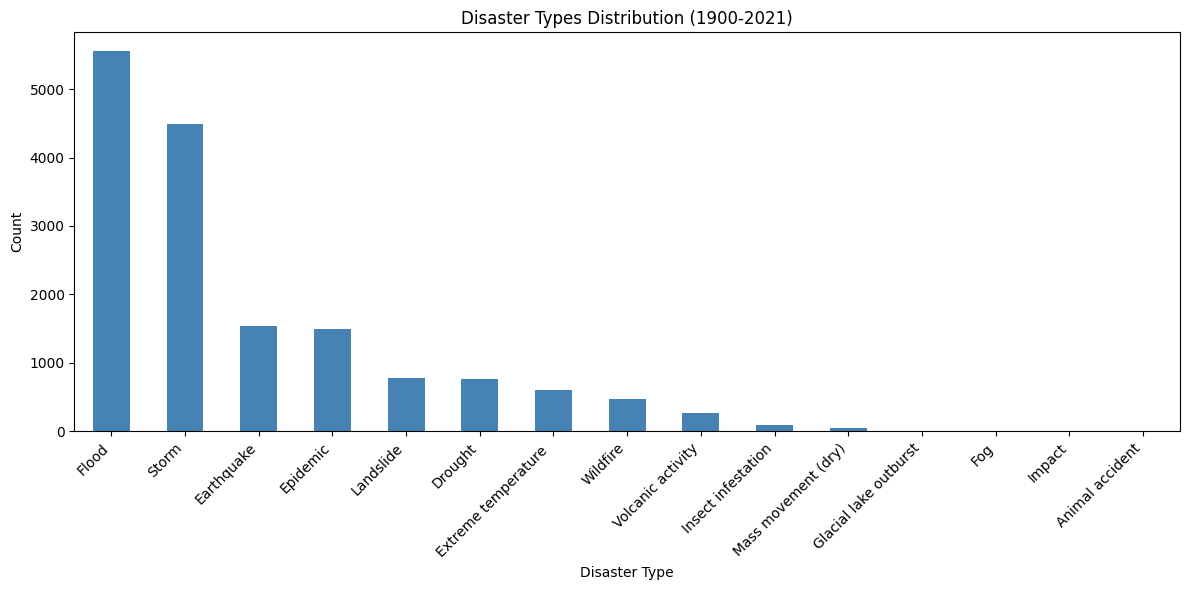

✅ Chart 1 saved!


In [ ]:
# Graph 1 - How many disaster types are there?
plt.figure(figsize=(12,6))
df_clean['Disaster Type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Disaster Types Distribution (1900-2021)')
plt.xlabel('Disaster Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/chart1_disaster_types.png')
plt.show()
print("✅ Chart 1 saved!")

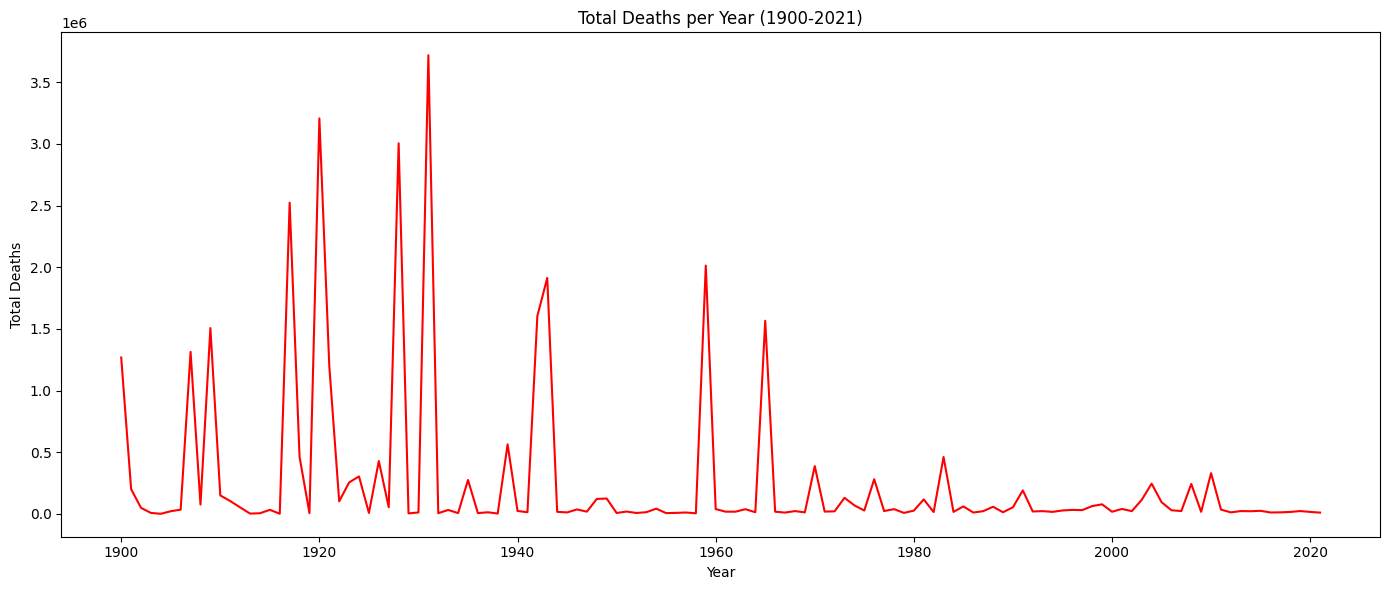

✅ Chart 2 saved!


In [ ]:
# Graph 2 - How many deaths occurred each year?
plt.figure(figsize=(14,6))
deaths_per_year = df_clean.groupby('Year')['Total Deaths'].sum()
deaths_per_year.plot(kind='line', color='red')
plt.title('Total Deaths per Year (1900-2021)')
plt.xlabel('Year')
plt.ylabel('Total Deaths')
plt.tight_layout()
plt.savefig('data/chart2_deaths_per_year.png')
plt.show()
print("✅ Chart 2 saved!")

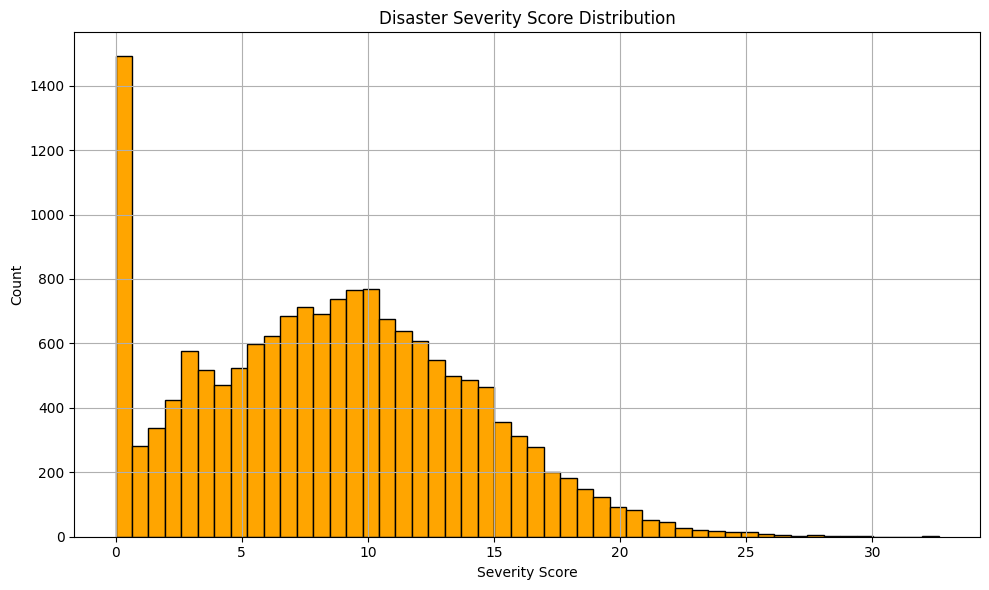

✅ Chart 3 saved!

Severity Score Stats:
count    16126.000000
mean         8.625294
std          5.414609
min          0.000000
25%          4.465908
50%          8.565507
75%         12.370059
max         32.641657
Name: severity_score, dtype: float64


In [ ]:
# Create a severity score.
import numpy as np

df_clean['severity_score'] = (
    np.log1p(df_clean['Total Deaths']) +
    np.log1p(df_clean['Total Affected'])
)

# Let’s look at the distribution of the severity score.
plt.figure(figsize=(10,6))
df_clean['severity_score'].hist(bins=50, color='orange', edgecolor='black')
plt.title('Disaster Severity Score Distribution')
plt.xlabel('Severity Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('data/chart3_severity_score.png')
plt.show()

print("✅ Chart 3 saved!")
print("\nSeverity Score Stats:")
print(df_clean['severity_score'].describe())

=== INDIA DISASTER ANALYSIS ===

India Total Disasters: 752
Global Total Disasters: 16126


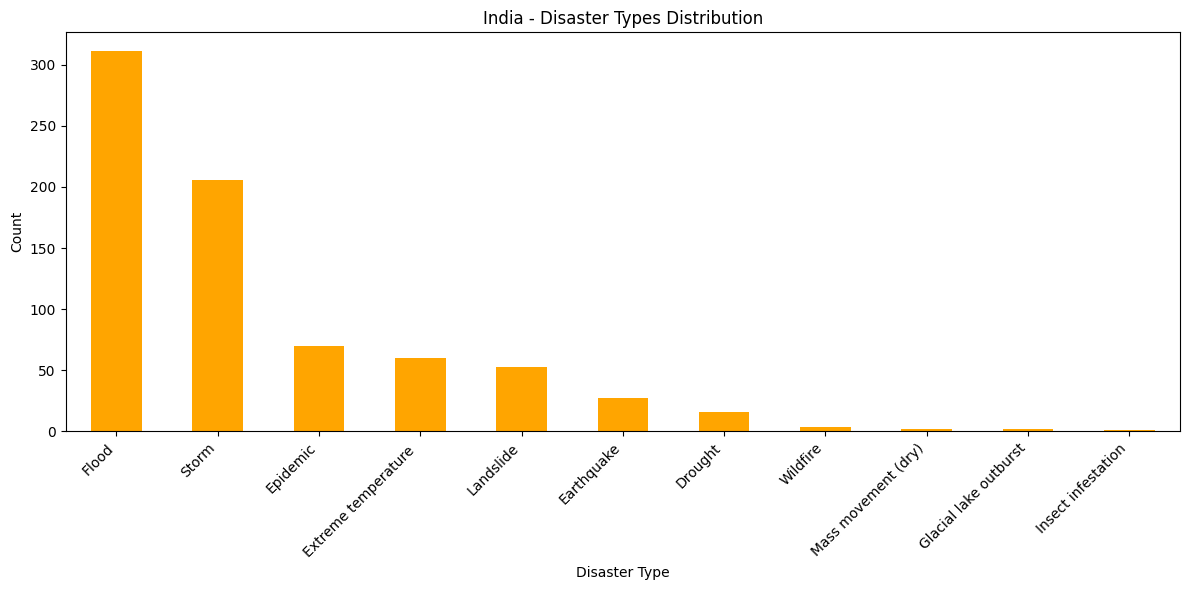

✅ India Chart saved!


In [ ]:
# India Specific Analysis
print("=== INDIA DISASTER ANALYSIS ===\n")

# Filter the data for India.
df_india = df_clean[df_clean['Country'] == 'India'].copy()
print(f"India Total Disasters: {len(df_india)}")
print(f"Global Total Disasters: {len(df_clean)}")

# Graph 1 - India Disaster Types
plt.figure(figsize=(12,6))
df_india['Disaster Type'].value_counts().plot(kind='bar', color='orange')
plt.title('India - Disaster Types Distribution')
plt.xlabel('Disaster Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('data/chart4_india_disaster_types.png')
plt.show()
print("✅ India Chart saved!")

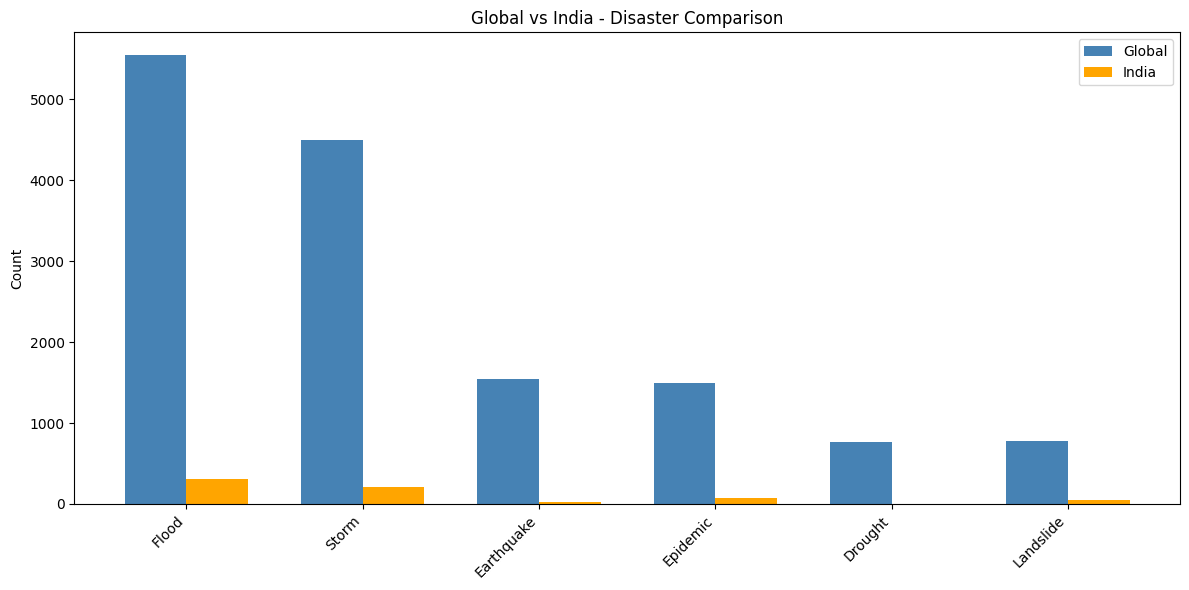

✅ Global vs India Chart saved!


In [ ]:
# Global vs India Comparison
global_counts = df_clean['Disaster Type'].value_counts().head(6)
india_counts = df_india['Disaster Type'].value_counts().head(6)

# Select the most common disaster types.
common_types = ['Flood', 'Storm', 'Earthquake', 'Epidemic', 'Drought', 'Landslide']

global_vals = [global_counts.get(t, 0) for t in common_types]
india_vals = [india_counts.get(t, 0) for t in common_types]

x = range(len(common_types))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], global_vals, width, 
               label='Global', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], india_vals, width, 
               label='India', color='orange')

ax.set_title('Global vs India - Disaster Comparison')
ax.set_xticks(list(x))
ax.set_xticklabels(common_types, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('data/chart_global_vs_india.png')
plt.show()
print("✅ Global vs India Chart saved!")

In [12]:
# Specific Disaster + Year Analysis Function
def disaster_analysis(disaster_type, year):
    print(f"=== {disaster_type} Analysis for {year} ===\n")
    
    # Filter data
    filtered = df_clean[
        (df_clean['Disaster Type'] == disaster_type) & 
        (df_clean['Year'] == year)
    ]
    
    if len(filtered) == 0:
        print(f"No {disaster_type} found in {year}")
        return
    
    damage_col = "Total Damages ('000 US$)"
    
    print(f"Total Events: {len(filtered)}")
    print(f"Total Deaths: {filtered['Total Deaths'].sum():,.0f}")
    print(f"Total Affected: {filtered['Total Affected'].sum():,.0f}")
    print(f"Total Damage: ${filtered[damage_col].sum():,.0f} (000 USD)")
    print(f"\nCountries Affected:")
    print(filtered['Country'].value_counts().to_string())
    print(f"\nRegions Affected:")
    print(filtered['Region'].value_counts().to_string())

# Test Examples
disaster_analysis("Earthquake", 1900)
print("\n" + "="*50 + "\n")
disaster_analysis("Flood", 1950)
print("\n" + "="*50 + "\n")
disaster_analysis("Earthquake", 2010)

=== Earthquake Analysis for 1900 ===

Total Events: 1
Total Deaths: 140
Total Affected: 0
Total Damage: $0 (000 USD)

Countries Affected:
Country
Turkey    1

Regions Affected:
Region
Western Asia    1


=== Flood Analysis for 1950 ===

Total Events: 10
Total Deaths: 3,808
Total Affected: 10,132,000
Total Damage: $100,000 (000 USD)

Countries Affected:
Country
India                             2
Japan                             2
Canada                            1
China                             1
Ecuador                           1
Iran (Islamic Republic of)        1
Pakistan                          1
United States of America (the)    1

Regions Affected:
Region
Southern Asia       4
Eastern Asia        3
Northern America    2
South America       1


=== Earthquake Analysis for 2010 ===

Total Events: 24
Total Deaths: 226,733
Total Affected: 6,936,980
Total Damage: $47,300,660 (000 USD)

Countries Affected:
Country
Iran (Islamic Republic of)        6
China                        

In [14]:
# 1. Earthquake 1900
disaster_analysis("Earthquake", 1900)
print("\n" + "="*50 + "\n")

# 2. Flood 2004 (Tsunami year)
disaster_analysis("Flood", 2004)
print("\n" + "="*50 + "\n")

# 3. Earthquake 2010 (Haiti)
disaster_analysis("Earthquake", 2010)
print("\n" + "="*50 + "\n")

# 4. Drought 1983
disaster_analysis("Drought", 1983)
print("\n" + "="*50 + "\n")

# 5. Storm 2005 (Katrina year)
disaster_analysis("Storm", 2005)
print("\n" + "="*50 + "\n")

# 6. Epidemic 2020 (COVID year)
disaster_analysis("Epidemic", 2020)

=== Earthquake Analysis for 1900 ===

Total Events: 1
Total Deaths: 140
Total Affected: 0
Total Damage: $0 (000 USD)

Countries Affected:
Country
Turkey    1

Regions Affected:
Region
Western Asia    1


=== Flood Analysis for 2004 ===

Total Events: 128
Total Deaths: 6,982
Total Affected: 116,990,815
Total Damage: $10,383,038 (000 USD)

Countries Affected:
Country
China                                                         9
India                                                         6
Nigeria                                                       5
United States of America (the)                                4
Angola                                                        3
Australia                                                     3
Bangladesh                                                    3
Panama                                                        3
Philippines (the)                                             3
Turkey                                                  

In [ ]:
# Disasters with the highest number of deaths.
print("=== TOP 10 DEADLIEST DISASTERS ===\n")
top10 = df_clean.nlargest(10, 'Total Deaths')[
    ['Year', 'Disaster Type', 'Country', 'Total Deaths', 'Total Affected']
]
print(top10.to_string())

=== TOP 10 DEADLIEST DISASTERS ===

      Year Disaster Type       Country  Total Deaths  Total Affected
111   1931         Flood         China     3700000.0             0.0
97    1928       Drought         China     3000000.0             0.0
902   1917      Epidemic  Soviet Union     2500000.0             0.0
58    1920      Epidemic         India     2000000.0             0.0
276   1959         Flood         China     2000000.0             0.0
152   1943       Drought    Bangladesh     1900000.0             0.0
20    1909      Epidemic         China     1500000.0             0.0
145   1942       Drought         India     1500000.0             0.0
1355  1965       Drought         India     1500000.0     100000000.0
16    1907      Epidemic         India     1300000.0             0.0


In [ ]:
import pickle
import numpy as np

# Load the model and the label encoder.
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print("✅ Model loaded!")
print("✅ Label Encoder loaded!")
print("Disaster Types:", le.classes_)

✅ Model loaded!
✅ Label Encoder loaded!
Disaster Types: ['Animal accident' 'Drought' 'Earthquake' 'Epidemic'
 'Extreme temperature ' 'Flood' 'Fog' 'Glacial lake outburst' 'Impact'
 'Insect infestation' 'Landslide' 'Mass movement (dry)' 'Storm'
 'Volcanic activity' 'Wildfire']


In [18]:
# Prediction Function 
def predict_disaster(disaster_type, year, deaths, affected, damages):
    print(f"=== Disaster Prediction ===")
    print(f"Disaster Type: {disaster_type}")
    print(f"Year: {year}")
    print(f"Deaths: {deaths}")
    print(f"Affected: {affected}")
    print(f"Damages: ${damages},000 USD")
    print()
    
    # Encode disaster type
    disaster_encoded = le.transform([disaster_type])[0]
    
    # Features
    X_new = [[year, deaths, affected, damages, disaster_encoded]]
    
    # Predict
    pred = model.predict(X_new)[0]
    pred_proba = model.predict_proba(X_new)[0]
    
    labels = {0: "Low 🟢", 1: "Medium 🟡", 2: "High 🔴"}
    
    print(f"Predicted Severity: {labels[pred]}")
    print(f"\nProbability:")
    print(f"  Low:    {pred_proba[0]*100:.2f}%")
    print(f"  Medium: {pred_proba[1]*100:.2f}%")
    print(f"  High:   {pred_proba[2]*100:.2f}%")

# Example Predictions
print("PREDICTION 1:")
predict_disaster("Flood", 2024, 500, 100000, 5000000)
print("\n" + "="*40 + "\n")

print("PREDICTION 2:")
predict_disaster("Earthquake", 2023, 10000, 500000, 10000000)
print("\n" + "="*40 + "\n")

print("PREDICTION 3:")
predict_disaster("Drought", 2022, 100, 50000, 1000000)

PREDICTION 1:
=== Disaster Prediction ===
Disaster Type: Flood
Year: 2024
Deaths: 500
Affected: 100000
Damages: $5000000,000 USD

Predicted Severity: Medium 🟡

Probability:
  Low:    0.00%
  Medium: 100.00%
  High:   0.00%


PREDICTION 2:
=== Disaster Prediction ===
Disaster Type: Earthquake
Year: 2023
Deaths: 10000
Affected: 500000
Damages: $10000000,000 USD

Predicted Severity: High 🔴

Probability:
  Low:    0.08%
  Medium: 15.46%
  High:   84.46%


PREDICTION 3:
=== Disaster Prediction ===
Disaster Type: Drought
Year: 2022
Deaths: 100
Affected: 50000
Damages: $1000000,000 USD

Predicted Severity: Medium 🟡

Probability:
  Low:    0.00%
  Medium: 100.00%
  High:   0.00%


In [ ]:
import numpy as np
from datetime import datetime

def disaster_alert_system(country, month):
    print(f"🔔 DISASTER ALERT SYSTEM")
    print(f"Country: {country} | Month: {month}")
    print("="*50)
    
    # Filter the historical data.
    country_data = df_clean[df_clean['Country'] == country]
    
    if len(country_data) == 0:
        print(f"❌ No historical data for {country}")
        return
    
    # Disasters by month.
    original_df = pd.read_csv(
        'data/1900_2021_DISASTERS.xlsx - emdat data.csv',
        encoding='latin-1'
    )
    
    country_month = original_df[
        (original_df['Country'] == country) & 
        (original_df['Start Month'] == month)
    ]
    
    # Disaster type count
    disaster_counts = country_month['Disaster Type'].value_counts()
    
    print(f"\n📊 Historical Disasters in Month {month}:")
    print(disaster_counts.to_string())
    
    print(f"\n⚠️ RISK ALERTS:")
    
    for disaster, count in disaster_counts.items():
        if count >= 10:
            risk = "🔴 HIGH RISK"
        elif count >= 5:
            risk = "🟡 MEDIUM RISK"
        else:
            risk = "🟢 LOW RISK"
        print(f"{risk} — {disaster} ({count} times historically)")
    
    # Top 3 dangerous disasters
    if len(disaster_counts) > 0:
        top_disaster = disaster_counts.index[0]
        print(f"\n🚨 MAIN ALERT:")
        print(f"Most likely disaster: {top_disaster}")
        print(f"Recommendation: Prepare for {top_disaster}!")
        print(f"→ Alert authorities")
        print(f"→ Prepare emergency kits")
        print(f"→ Evacuate low-lying areas if needed")

# Test it — India, June (monsoon month).
disaster_alert_system("India", 6)
print("\n" + "="*50 + "\n")

# Bangladesh, May
disaster_alert_system("Bangladesh", 5)

🔔 DISASTER ALERT SYSTEM
Country: India | Month: 6

📊 Historical Disasters in Month 6:
Disaster Type
Flood                   49
Storm                   16
Landslide                8
Extreme temperature      7
Epidemic                 6
Drought                  1

⚠️ RISK ALERTS:
🔴 HIGH RISK — Flood (49 times historically)
🔴 HIGH RISK — Storm (16 times historically)
🟡 MEDIUM RISK — Landslide (8 times historically)
🟡 MEDIUM RISK — Extreme temperature  (7 times historically)
🟡 MEDIUM RISK — Epidemic (6 times historically)
🟢 LOW RISK — Drought (1 times historically)

🚨 MAIN ALERT:
Most likely disaster: Flood
Recommendation: Prepare for Flood!
→ Alert authorities
→ Prepare emergency kits
→ Evacuate low-lying areas if needed


🔔 DISASTER ALERT SYSTEM
Country: Bangladesh | Month: 5

📊 Historical Disasters in Month 5:
Disaster Type
Storm                   50
Flood                    8
Epidemic                 3
Extreme temperature      1

⚠️ RISK ALERTS:
🔴 HIGH RISK — Storm (50 times historical

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data.
df_clean = pd.read_csv('data/disasters_clean.csv')
print("✅ Data loaded!")
print("Shape:", df_clean.shape)

✅ Data loaded!
Shape: (16126, 13)
